# Scene depth: breadth, concentration and follower output

## tl;dr

In the mapped top-1,000 catalogue, London has the broadest follower base with
an effective-band count of **20.2**, followed
by Glasgow (**10.7**) and Manchester
(**9.7**). Crawley has the highest
follower output quotient (**3.59×**) but
an effective-band count of **1.0**. Sheffield
combines a **2.72×** quotient with
**2.4** effective bands, while its largest
band supplies **63%** of mapped followers.

## Context & Methods

Counting selected bands does not describe how follower attention is
distributed. This experiment calculates, for each mapped FUA:

- inverse Herfindahl effective-band count;
- largest-band and top-three follower shares;
- median mapped-band followers; and
- the number of mapped bands above 100,000 followers.

It then compares scene breadth with the follower output quotient already used
in the top-1,000 output-share experiment.

### Key Assumptions

The measures describe the selected popularity-first catalogue, not every band
formed in an FUA. Spotify followers are accumulated platform audiences rather
than local participation or historical influence.

## Data

Build the metrics from the frozen top-1,000 selection and reviewed FUA map.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src/python_uk_bands").exists():
    ROOT = next(
        parent for parent in Path.cwd().resolve().parents
        if (parent / "src/python_uk_bands").exists()
    )
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ARTIFACT_DIR = ROOT / "artifacts/experiments/scene_depth_concentration/20260718T204522Z"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
from python_uk_bands.review_experiments import (
    build_top1000_scene_depth,
    plot_depth_vs_output,
    plot_effective_band_ranking,
)

depth, mapped_bands, coverage = build_top1000_scene_depth(ROOT)

assert len(mapped_bands) == coverage["mapped_bands"]
assert depth["effective_band_count"].le(depth["band_count"] + 1e-9).all()
assert depth["largest_band_share"].between(0, 1).all()
assert depth["top_three_share"].between(0, 1).all()

depth.to_csv(ARTIFACT_DIR / "scene_depth_metrics.csv", index=False)
mapped_bands.to_csv(ARTIFACT_DIR / "mapped_band_inputs.csv", index=False)
(ARTIFACT_DIR / "coverage_summary.json").write_text(
    json.dumps(coverage, indent=2, sort_keys=True) + "\n"
)

display(Markdown(
    f"**{coverage['mapped_bands']} mapped bands · "
    f"{len(depth)} positive-output FUAs · "
    f"{coverage['mapped_follower_share']:.1%} of selected followers mapped**"
))

**660 mapped bands · 61 positive-output FUAs · 92.4% of selected followers mapped**

## Results

### 1. Which FUAs have the broadest follower distributions?

In [3]:
display(depth.head(20)[[
    "study_city_label",
    "band_count",
    "effective_band_count",
    "largest_band_share",
    "top_three_share",
    "bands_above_threshold",
    "follower_output_quotient",
]].style.hide(axis="index").format({
    "effective_band_count": "{:.2f}",
    "largest_band_share": "{:.1%}",
    "top_three_share": "{:.1%}",
    "follower_output_quotient": "{:.2f}×",
}))

study_city_label,band_count,effective_band_count,largest_band_share,top_three_share,bands_above_threshold,follower_output_quotient
London,299,20.24,13.1%,33.4%,213,2.28×
Glasgow,31,10.70,18.9%,44.3%,21,0.53×
Manchester,52,9.66,22.5%,50.4%,38,1.03×
Leeds,24,5.99,34.8%,57.6%,15,0.19×
Birmingham,28,5.40,35.8%,64.8%,18,0.54×
Edinburgh,15,4.73,39.5%,65.0%,9,0.28×
Brighton and Hove,15,4.00,38.5%,82.5%,9,0.92×
Southampton,4,3.51,33.4%,90.4%,4,0.09×
Coventry,7,3.46,46.2%,81.8%,4,0.12×
Cardiff,12,3.07,52.0%,79.1%,5,0.22×


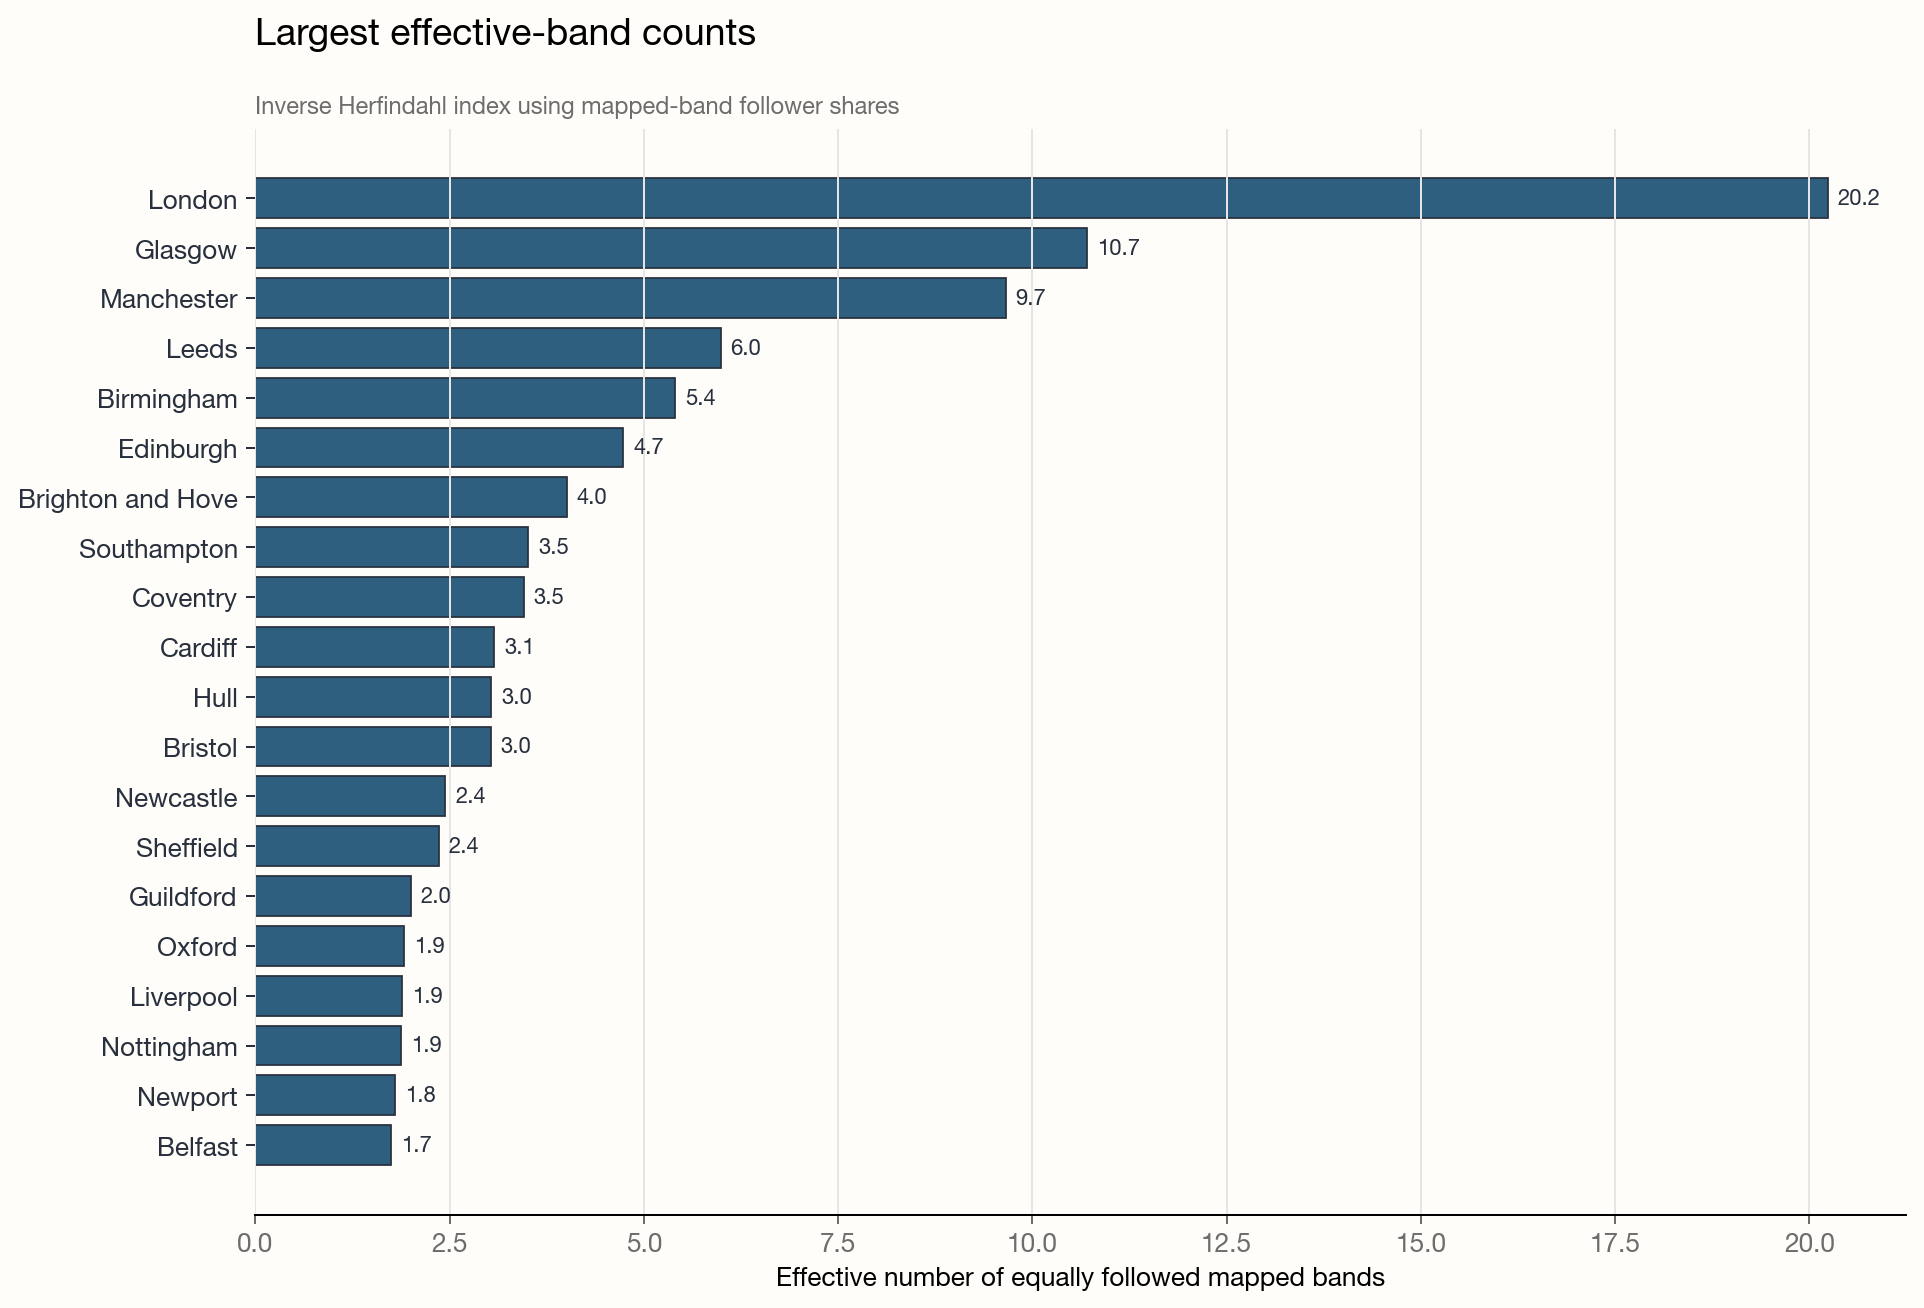

In [4]:
ranking_path = plot_effective_band_ranking(
    depth,
    output_path=ARTIFACT_DIR / "chart_01_effective_band_ranking.png",
)
display(Image(filename=str(ranking_path)))

### 2. Does high population-adjusted output imply a broad scene?

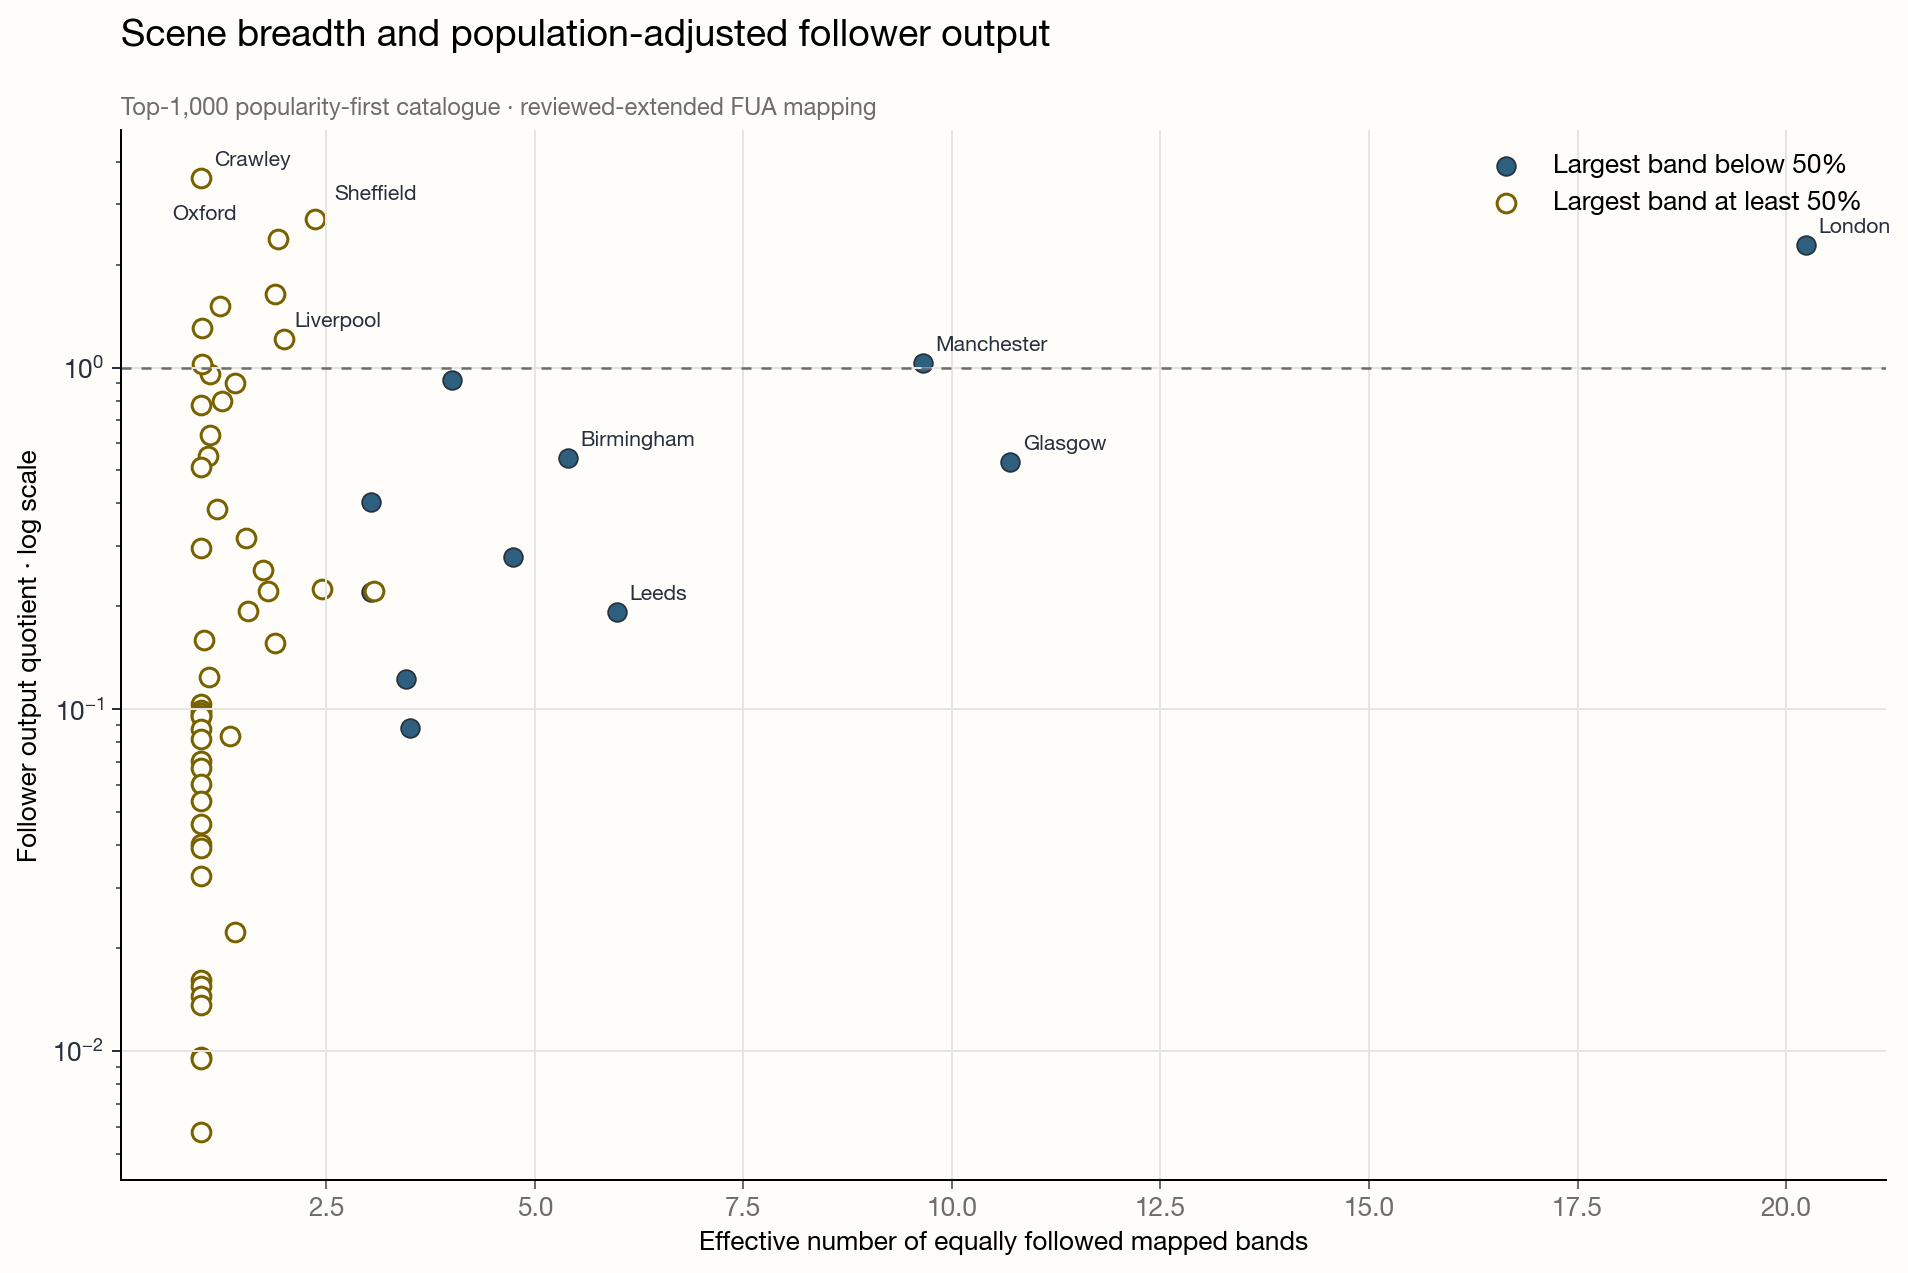

In [5]:
label_cities = (
    set(depth.head(5)["study_city_label"])
    | set(depth.nlargest(5, "follower_output_quotient")["study_city_label"])
)
relationship_path = plot_depth_vs_output(
    depth,
    output_path=ARTIFACT_DIR / "chart_02_depth_vs_output.png",
    label_cities=sorted(label_cities),
)
display(Image(filename=str(relationship_path)))

## Takeaways

- Output and depth answer different questions: a city can have an exceptional
  population-adjusted audience while depending on one dominant band.
- London, Glasgow and Manchester have the broadest follower distributions in
  this selected catalogue.
- Crawley, Hastings and Exeter illustrate why a high output quotient should not
  be described as scene depth.
- Effective-band count, concentration and threshold counts should accompany
  future normalized rankings.